In [6]:
!pip install sentence-transformers seaborn matplotlib

from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [7]:
sentences = [
    # Cricket
    "The batsman scored a century in the final match",
    "The bowler delivered a fast yorker to take the wicket",
    "The team won the cricket tournament after a thrilling chase",

    # Cooking
    "The chef prepared a delicious pasta with fresh ingredients",
    "Baking a cake requires precise measurements and timing",
    "Spices add flavor and aroma to Indian dishes",

    # Cybersecurity
    "Strong passwords help protect user accounts from hackers",
    "Phishing attacks trick users into revealing sensitive information",
    "Encryption ensures secure communication over the internet",

    # Extra (to make 10)
    "The cricket match was interrupted due to rain"
]

In [3]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

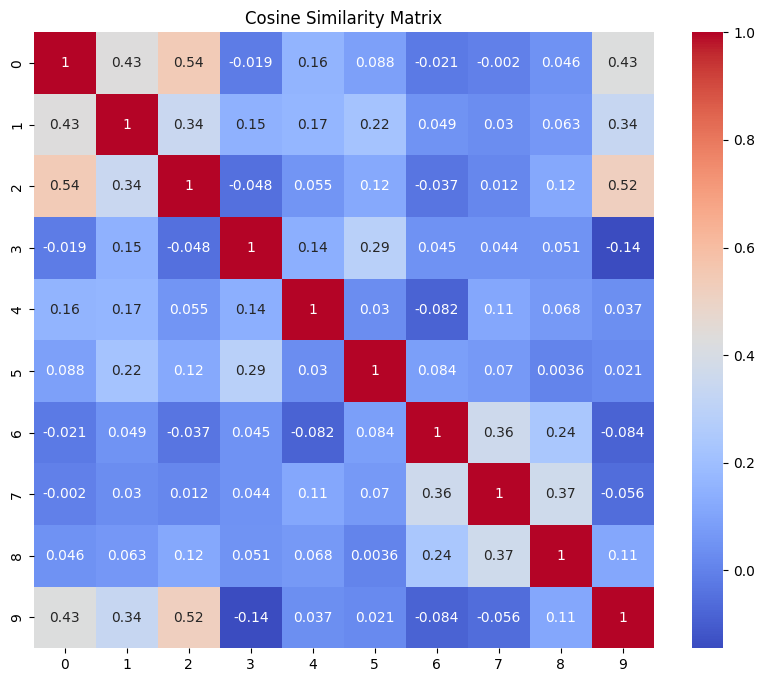

In [4]:
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

In [5]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 matches
top_indices = similarities.argsort()[-2:][::-1]

for i in top_indices:
    print("Sentence:", sentences[i])
    print("Similarity Score:", similarities[i])
    print()

Sentence: The bowler delivered a fast yorker to take the wicket
Similarity Score: 0.6662836

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5706849

